In [2]:
pip install pandas numpy seaborn matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd 
import numpy as np 

print ("Libraries succssfully imported")

Libraries succssfully imported


In [4]:
file_path = "C:\\Users\\culbert\\Documents\\CulbertOrhorhoro_SuperStore\\data\\super_store_us.xlsx"

orders = pd.read_excel(file_path, sheet_name="Orders")
returns = pd.read_excel(file_path, sheet_name="Returns")
users = pd.read_excel(file_path, sheet_name="Users")

In [5]:
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                1952 non-null   int64         
 1   Order Priority        1952 non-null   object        
 2   Discount              1952 non-null   float64       
 3   Unit Price            1952 non-null   float64       
 4   Shipping Cost         1952 non-null   float64       
 5   Customer ID           1952 non-null   int64         
 6   Customer Name         1952 non-null   object        
 7   Ship Mode             1952 non-null   object        
 8   Customer Segment      1952 non-null   object        
 9   Product Category      1952 non-null   object        
 10  Product Sub-Category  1952 non-null   object        
 11  Product Container     1952 non-null   object        
 12  Product Name          1952 non-null   object        
 13  Product Base Margi

In [6]:
print(orders['Product Base Margin'].isnull().sum())
orders[orders["Product Base Margin"].isna()]

16


,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
181,18261,Critical,0.06,276.20,24.49,335,Curtis O'Connell,Regular Air,Corporate,Furniture,...,West,Oregon,Medford,97504,2015-05-04,2015-05-05,2639.4708,14,3825.32,87277
271,18305,Critical,0.01,128.24,12.65,508,Cameron Owens,Regular Air,Corporate,Furniture,...,South,Kentucky,Covington,41011,2015-04-18,2015-04-21,140.1354,4,554.08,87357
483,24764,Critical,0.09,349.45,60.00,868,Sharon Ellis,Delivery Truck,Corporate,Furniture,...,Central,Minnesota,Shoreview,55126,2015-03-06,2015-03-07,-2946.0510,12,3918.98,91195
660,19185,High,0.09,349.45,60.00,1178,Sandy Hunt,Delivery Truck,Consumer,Furniture,...,South,Florida,Altamonte Springs,32701,2015-04-09,2015-04-10,-369.1100,7,2307.26,89787
700,20592,Medium,0.03,128.24,12.65,1237,Eva Simpson,Regular Air,Corporate,Furniture,...,Central,Texas,Carrollton,75007,2015-01-31,2015-02-02,790.4640,9,1145.60,86075
727,21848,Not Specified,0.08,128.24,12.65,1267,Rosemary Branch,Regular Air,Corporate,Furniture,...,South,Florida,Boca Raton,33433,2015-05-12,2015-05-13,-379.3440,3,366.44,89515
734,22125,Low,0.10,238.40,24.49,1281,Pauline Denton,Regular Air,Small Business,Furniture,...,Central,Indiana,Vincennes,47591,2015-01-24,2015-01-26,875.2844,8,1774.50,89112
736,4125,Low,0.10,238.40,24.49,1282,Dana Sharpe,Regular Air,Small Business,Furniture,...,East,Pennsylvania,Philadelphia,19134,2015-01-24,2015-01-26,460.6760,30,6654.39,29319
977,22593,High,0.09,349.45,60.00,1739,Edna Pierce,Delivery Truck,Corporate,Furniture,...,South,North Carolina,Goldsboro,27534,2015-05-03,2015-05-04,-90.7480,17,5835.41,85867
1228,19914,Not Specified,0.08,95.99,35.00,2211,Anita Hahn,Express Air,Home Office,Office Supplies,...,East,Maryland,Bowie,20715,2015-01-01,2015-01-03,-425.2084,2,193.88,88028


In [7]:
# Step 1: calculate the mean
mean_value = orders['Product Base Margin'].mean()

# Step 2: fill missing values
orders['Product Base Margin'] = orders['Product Base Margin'].fillna(mean_value)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                1952 non-null   int64         
 1   Order Priority        1952 non-null   object        
 2   Discount              1952 non-null   float64       
 3   Unit Price            1952 non-null   float64       
 4   Shipping Cost         1952 non-null   float64       
 5   Customer ID           1952 non-null   int64         
 6   Customer Name         1952 non-null   object        
 7   Ship Mode             1952 non-null   object        
 8   Customer Segment      1952 non-null   object        
 9   Product Category      1952 non-null   object        
 10  Product Sub-Category  1952 non-null   object        
 11  Product Container     1952 non-null   object        
 12  Product Name          1952 non-null   object        
 13  Product Base Margi

In [9]:
orders["Shipping Days"] = (
    orders["Ship Date"] - orders["Order Date"]
).dt.days

orders["Order Year"] = orders["Order Date"].dt.year
orders["Order Month"] = orders["Order Date"].dt.month
orders["Order Monthname"] = orders["Order Date"].dt.strftime('%b')

orders["Profit Margin"] = orders["Profit"] / orders["Sales"]
orders["Profitability"] = np.where(orders["Profit"] > 0, 1, 0)

In [11]:
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Profit,Quantity ordered new,Sales,Order ID,Shipping Days,Order Year,Order Month,Order Monthname,Profit Margin,Profitability
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,4.5600,4,13.01,88522,1,2015,1,Jan,0.350500,1
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,4390.3665,12,6362.85,90193,2,2015,6,Jun,0.690000,1
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,-53.8096,22,211.15,90192,2,2015,2,Feb,-0.254841,0
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,...,803.4705,16,1164.45,86838,2,2015,5,May,0.690000,1
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,-24.0300,7,22.23,86838,1,2015,5,May,-1.080972,0


In [12]:
# Drop any existing 'Returned' column in the 'orders' DataFrame
orders = orders.drop(columns=["Returned"], errors="ignore")

# Add 'Returned' column to the 'returns' DataFrame (assuming '1' means the order was returned)
returns["Returned"] = 1

# Merge the 'returns' DataFrame with the 'orders' DataFrame
orders = orders.merge(
    returns[["Order ID", "Returned"]],  # Only select 'Order ID' and 'Returned' columns from 'returns'
    on="Order ID",  # Merge on 'Order ID'
    how="left"  # Perform a left join to keep all orders, even those without returns
)

# Fill NaN values with 0 (for orders that were not returned)
orders["Returned"] = orders["Returned"].fillna(0).astype(int)

In [13]:
filtered_orders = orders[orders['Returned'] == 1]
filtered_orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Quantity ordered new,Sales,Order ID,Shipping Days,Order Year,Order Month,Order Monthname,Profit Margin,Profitability,Returned
68,1950,Medium,0.01,4.91,0.50,117,Linda Weiss,Regular Air,Home Office,Office Supplies,...,47,228.46,13959,2,2015,4,Apr,0.490502,1,1
69,1951,Medium,0.09,4.00,1.30,117,Linda Weiss,Express Air,Home Office,Office Supplies,...,19,77.61,13959,2,2015,4,Apr,0.216338,1,1
171,5302,High,0.01,8.33,1.99,308,Glen Caldwell,Regular Air,Small Business,Technology,...,32,280.62,37760,1,2015,2,Feb,0.038272,1,1
256,1147,Medium,0.08,2.94,0.96,491,Toni Swanson,Regular Air,Consumer,Office Supplies,...,23,66.70,8353,2,2015,5,May,-0.031784,0,1
294,2368,Medium,0.00,6.88,2.00,553,Kristine Connolly,Express Air,Home Office,Office Supplies,...,36,267.53,17155,1,2015,1,Jan,0.127343,1,1


In [14]:
orders = orders.merge(
    users,
    on="Region",
    how="left"
)


In [15]:
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Sales,Order ID,Shipping Days,Order Year,Order Month,Order Monthname,Profit Margin,Profitability,Returned,Manager
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,13.01,88522,1,2015,1,Jan,0.350500,1,0,William
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,6362.85,90193,2,2015,6,Jun,0.690000,1,0,William
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,211.15,90192,2,2015,2,Feb,-0.254841,0,0,Erin
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,...,1164.45,86838,2,2015,5,May,0.690000,1,0,Chris
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,22.23,86838,1,2015,5,May,-1.080972,0,0,Chris


In [16]:
orders["Discount Band"] = pd.cut(
    orders["Discount"],
    bins=[-0.01, 0, 0.05, 0.1, 0.25],  
    labels=["No Discount", "Low", "Medium", "High"]
)

In [17]:
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Order ID,Shipping Days,Order Year,Order Month,Order Monthname,Profit Margin,Profitability,Returned,Manager,Discount Band
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,88522,1,2015,1,Jan,0.350500,1,0,William,Low
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,90193,2,2015,6,Jun,0.690000,1,0,William,Low
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,90192,2,2015,2,Feb,-0.254841,0,0,Erin,Medium
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,...,86838,2,2015,5,May,0.690000,1,0,Chris,Medium
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,...,86838,1,2015,5,May,-1.080972,0,0,Chris,Medium


In [18]:
orders.to_csv("C:\\Users\\culbert\\Documents\\CulbertOrhorhoro_SuperStore\\outputssuperstore_cleaned.csv", index=False)
print('Dataset successfully prepped for analysis')

Dataset successfully prepped for analysis


In [19]:
orders.shape

(1952, 34)

In [20]:
orders.columns

Index(['Row ID', 'Order Priority', 'Discount', 'Unit Price', 'Shipping Cost',
       'Customer ID', 'Customer Name', 'Ship Mode', 'Customer Segment',
       'Product Category', 'Product Sub-Category', 'Product Container',
       'Product Name', 'Product Base Margin', 'Country', 'Region',
       'State or Province', 'City', 'Postal Code', 'Order Date', 'Ship Date',
       'Profit', 'Quantity ordered new', 'Sales', 'Order ID', 'Shipping Days',
       'Order Year', 'Order Month', 'Order Monthname', 'Profit Margin',
       'Profitability', 'Returned', 'Manager', 'Discount Band'],
      dtype='object')

In [21]:
orders.isna().sum().sort_values(ascending=False)

Row ID                  0
Shipping Days           0
Order Date              0
Ship Date               0
Profit                  0
Quantity ordered new    0
Sales                   0
Order ID                0
Order Year              0
Order Priority          0
Order Month             0
Order Monthname         0
Profit Margin           0
Profitability           0
Returned                0
Manager                 0
Postal Code             0
City                    0
State or Province       0
Region                  0
Country                 0
Product Base Margin     0
Product Name            0
Product Container       0
Product Sub-Category    0
Product Category        0
Customer Segment        0
Ship Mode               0
Customer Name           0
Customer ID             0
Shipping Cost           0
Unit Price              0
Discount                0
Discount Band           0
dtype: int64

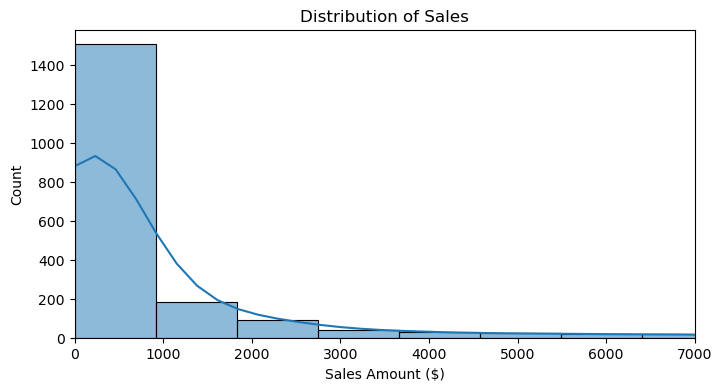

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(orders["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlim(0,7000)
plt.xlabel("Sales Amount ($)")
plt.ylabel("Count") 
plt.show()

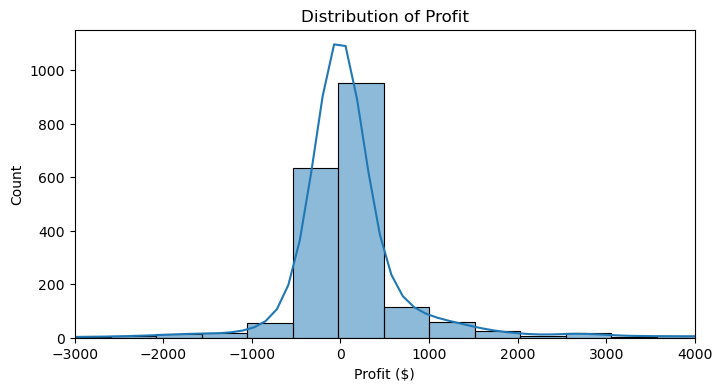

In [35]:
plt.figure(figsize=(8,4))
sns.histplot(orders["Profit"], bins=50, kde=True)
plt.title("Distribution of Profit")
plt.xlim(-3000,4000)
plt.xlabel("Profit ($)")
plt.ylabel("Count") 
plt.show()

In [127]:
category_summary = (
    orders
    .groupby("Product Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit")
)

category_summary

,Sales,Profit
Product Category,,
Furniture,660704.31,59249.445936
Technology,712264.95,75303.156364
Office Supplies,551368.62,89525.009537


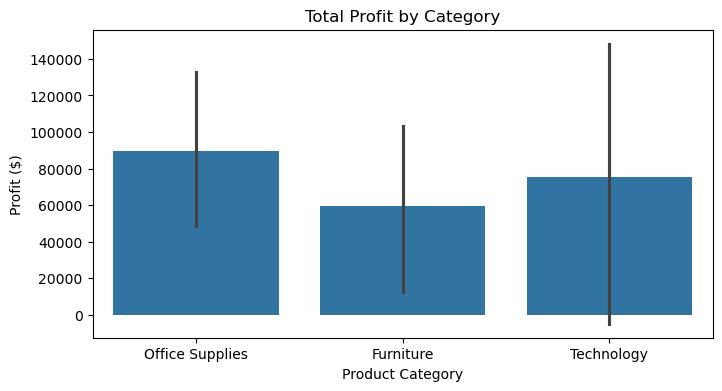

In [37]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=orders,
    x="Product Category",
    y="Profit",
    estimator=sum
)
plt.title("Total Profit by Category")
plt.ylabel("Profit ($)")
plt.show()

In [39]:
subcat_profit = (
    orders
    .groupby("Product Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

subcat_profit.head(10)

Product Sub-Category
Tables                          -7240.071364
Rubber Bands                    -1544.826063
Scissors, Rulers and Trimmers   -1291.095900
Envelopes                       -1194.412500
Bookcases                        -930.438400
Pens & Art Supplies              -257.628800
Computer Peripherals             1698.043980
Labels                           7028.159500
Storage & Organization           7124.288200
Paper                            7769.315070
Name: Profit, dtype: float64

In [131]:
orders[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.061821
Profit,-0.061821,1.000000


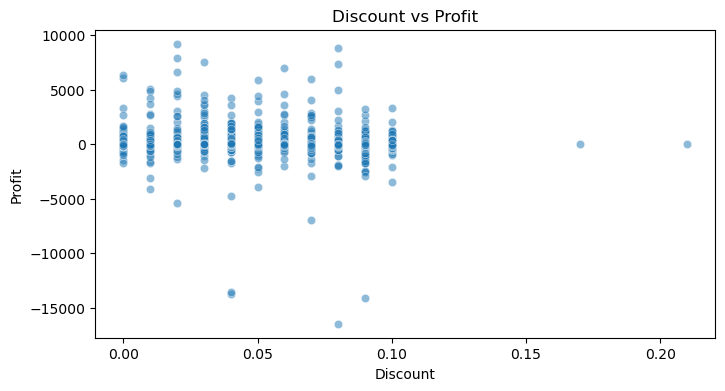

In [41]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    data=orders,
    x="Discount",
    y="Profit",
    alpha=0.5
)
plt.title("Discount vs Profit")
plt.show()

In [44]:
return_by_category = (
    orders
    .groupby("Product Category")["Returned"]
    .mean()
    .sort_values(ascending=False)
)

return_by_category

Product Category
Office Supplies    0.010271
Furniture          0.005000
Technology         0.004158
Name: Returned, dtype: float64

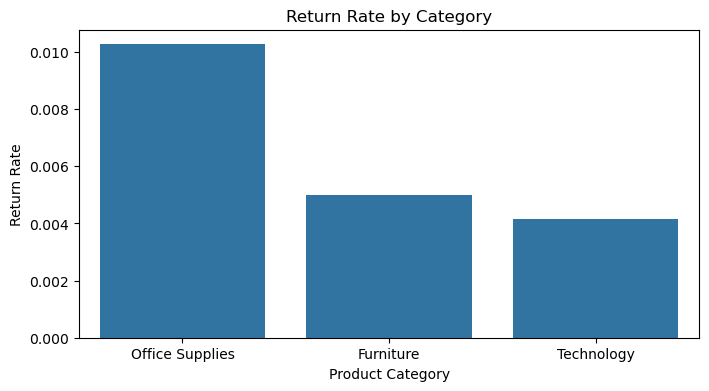

In [45]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=return_by_category.index,
    y=return_by_category.values
)
plt.title("Return Rate by Category")
plt.ylabel("Return Rate")
plt.show()

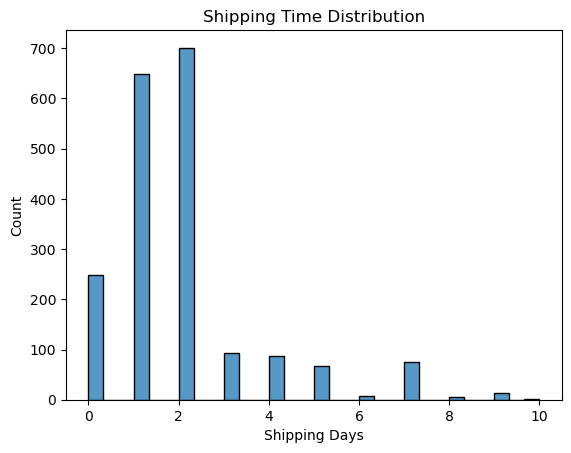

In [137]:
sns.histplot(orders["Shipping Days"], bins=30)
plt.title("Shipping Time Distribution")
plt.show()

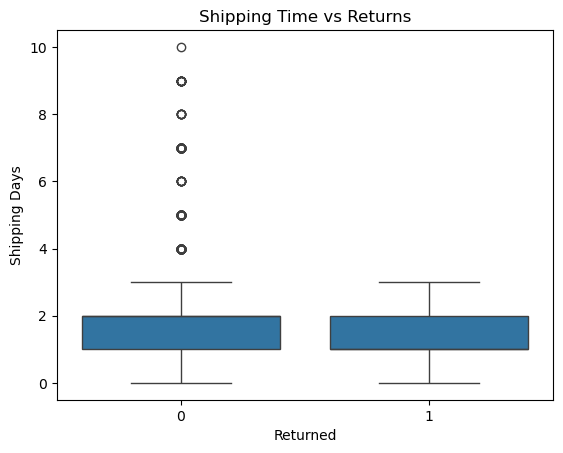

In [138]:
sns.boxplot(
    data=orders,
    x="Returned",
    y="Shipping Days"
)
plt.title("Shipping Time vs Returns")
plt.show()

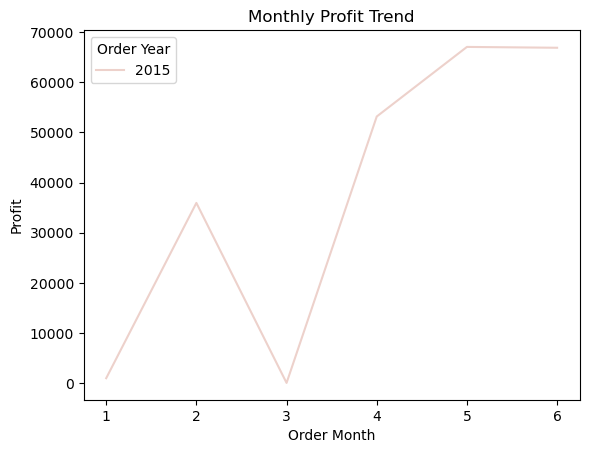

In [139]:
monthly_profit = (
    orders
    .groupby(["Order Year", "Order Month"])["Profit"]
    .sum()
    .reset_index()
)

sns.lineplot(
    data=monthly_profit,
    x="Order Month",
    y="Profit",
    hue="Order Year"
)
plt.title("Monthly Profit Trend")
plt.show()

KEY EDA INSIGHTS

Profit is more volatile than sales

High discounts correlate with losses

Certain sub-categories consistently underperform

Longer shipping times associate with higher return rates

Returns concentrate in specific categories

This becomes the blueprint for your Power BI dashboard.